In [1]:
import dill
from qiskit.circuit.library import QuantumVolume
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager, StagedPassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate, YGate
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator
from qiskit_ibm_runtime import IBMBackend
from qiskit.visualization import timeline_drawer
from qiskit.transpiler import Target

In [3]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

qubits = [7, 8, 9, 10, 17, 18, 19, 20, 27, 28, 29, 30]


methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "alap+dd+xpxm", "asap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]

valid_methods = methods_list + dd_methods_list + extra_dd_methods_list


In [3]:
# Read the CSV file
df = pd.read_csv("Fez-GHZ-extensive-benchmarking-sampler.csv")

# List of columns that contain string representations of dictionaries
# Based on the columns shown in your traceback
cols_to_eval = df.columns

def safe_literal_eval(val):
    """
    Safely evaluate a string containing a Python literal.
    Returns the original value if it's not a string or if evaluation fails.
    """
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return val
    return val

# Apply the conversion only to the relevant columns
for col in cols_to_eval:
    if col in df.columns:
        df[col] = df[col].apply(safe_literal_eval)

# Verify the data types
df.head()


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,none,asap,alap,asap+dd+xx,alap+dd+xx,alap+dd+xpxm,asap+dd+xpxm,asap+dd+xy,alap+dd+xy,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4slsksfitbs739j43k0,7,4096,"{'1111111': 2048, '0000000': 2048}","{'1111111': 2153, '0000000': 1943}","{'0000000': 1928, '0100000': 15, '1111111': 16...","{'1111111': 1665, '0000000': 1879, '0000010': ...","{'0000000': 1907, '1111111': 1672, '0001111': ...","{'0000000': 1805, '1011000': 1, '1111111': 163...","{'1111111': 1602, '0000000': 1857, '0000001': ...","{'1111111': 1615, '0000000': 1880, '0000011': ...","{'0000000': 1833, '1111111': 1622, '1100000': ...","{'1111111': 1642, '0000000': 1892, '0111111': ...","{'1111111': 1707, '0000000': 1827, '0010111': ...","[0.9993424263882965, 0.8767808045734468, 0.864...","[0.8745778053258384, 0.8625377175627317, 0.870..."
1,0,d4slsls5fjns73d2jje0,8,4096,"{'11111111': 2048, '00000000': 2048}","{'11111111': 2074, '00000000': 2022}","{'11111111': 1573, '00000000': 1931, '11101111...","{'11111111': 1564, '00000000': 1832, '00111111...","{'00000000': 1882, '11111111': 1671, '11011111...","{'00000000': 1823, '01000000': 14, '11111111':...","{'00000000': 1856, '11111111': 1595, '11110111...","{'11011101': 1, '11111111': 1628, '00000000': ...","{'00000000': 1790, '11111111': 1588, '11111011...","{'11100001': 1, '00000000': 1816, '11111111': ...","{'11111111': 1602, '00000000': 1896, '11111100...","[0.9999597056364962, 0.8532304421185956, 0.827...","[0.8526413518986303, 0.8273600489160481, 0.866..."
2,0,d4slsmbher1c73bdfi7g,9,4096,"{'111111111': 2048, '000000000': 2048}","{'111111111': 2070, '000000000': 2026}","{'111111111': 1355, '000000000': 1878, '111111...","{'111111111': 1325, '000000000': 1748, '110000...","{'111011111': 48, '111111111': 1427, '00000000...","{'111111111': 1315, '000000000': 1808, '111111...","{'101111111': 22, '111111111': 1364, '11111111...","{'111111110': 224, '000000000': 1846, '1111111...","{'000000000': 1766, '111111111': 1364, '111111...","{'000000000': 1803, '000000001': 57, '00100000...","{'000000000': 1847, '111111111': 1414, '011111...","[0.9999711505196361, 0.7841085083810232, 0.746...","[0.783400226178636, 0.7460971830501215, 0.7981..."
3,0,d4slsmsfitbs739j43n0,10,4096,"{'1111111111': 2048, '0000000000': 2048}","{'1111111111': 2017, '0000000000': 2079}","{'0000000000': 1874, '1111111111': 1337, '1011...","{'1010000000': 6, '1011011111': 4, '1111111111...","{'1111111111': 1368, '0000000000': 1898, '1011...","{'0000000000': 1707, '1111111111': 1373, '0000...","{'0000100000': 40, '0000000000': 1762, '111111...","{'1111111111': 1354, '0000000000': 1853, '1000...","{'0000111111': 21, '1111111111': 1353, '110000...","{'1111111111': 1365, '0000000000': 1721, '0111...","{'0000000000': 1851, '1011111111': 202, '11111...","[0.9999427166549892, 0.7784153151055028, 0.754...","[0.7793632796113626, 0.7556117094632328, 0.793..."
4,0,d4slsnk5fjns73d2jjgg,17,4096,"{'11111111111111111': 2048, '00000000000000000...","{'00000000000000000': 2081, '11111111111111111...","{'11111101111111111': 152, '11111111000000000'...","{'00000000000000000': 1432, '11111111110111111...","{'00000000000000000': 1759, '11111111111111111...","{'11100000000000000': 21, '00000000000000000':...","{'00000000000000111': 23, '11111111111111111':...","{'11111100111111111': 1, '00000000000000000': ...","{'11111000000011111': 2, '00000000000000000': ...","{'00000000000000000': 1314, '11111110111111111...","{'00000000000000000': 1461, '00000000000000010...","[0.9999350863280547, 0.6503878072638585, 0.544...","[0.651677897221708, 0.5453979926742467, 0.6634..."


In [7]:
df_iter = df[df["iteration"] == 0]

In [ ]:
df_iter[df_iter["Qubit"] == 7]["hellinger_fidelity(ideal)"]

,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,none,asap,alap,asap+dd+xx,alap+dd+xx,alap+dd+xpxm,asap+dd+xpxm,asap+dd+xy,alap+dd+xy,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4slsksfitbs739j43k0,7,4096,"{'1111111': 2048, '0000000': 2048}","{'1111111': 2153, '0000000': 1943}","{'0000000': 1928, '0100000': 15, '1111111': 16...","{'1111111': 1665, '0000000': 1879, '0000010': ...","{'0000000': 1907, '1111111': 1672, '0001111': ...","{'0000000': 1805, '1011000': 1, '1111111': 163...","{'1111111': 1602, '0000000': 1857, '0000001': ...","{'1111111': 1615, '0000000': 1880, '0000011': ...","{'0000000': 1833, '1111111': 1622, '1100000': ...","{'1111111': 1642, '0000000': 1892, '0111111': ...","{'1111111': 1707, '0000000': 1827, '0010111': ...","[0.9993424263882965, 0.8767808045734468, 0.864...","[0.8745778053258384, 0.8625377175627317, 0.870..."


In [2]:
service = QiskitRuntimeService()

torino = service.backend("ibm_torino")


management.get:WARNING:2025-12-15 13:03:27,051: Loading default saved account


In [3]:
from qiskit.circuit.library import QFT

n_qubits = 5
qc = QuantumCircuit(n_qubits)

qc.x(range(n_qubits))

qc.compose(QFT(num_qubits=n_qubits), inplace=True)

qc.barrier()

qc.compose(QFT(num_qubits=n_qubits, inverse=True), inplace=True)

qc.measure_all()

/tmp/ipykernel_7670/2034607160.py:8: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(num_qubits=n_qubits), inplace=True)
/tmp/ipykernel_7670/2034607160.py:12: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(num_qubits=n_qubits, inverse=True), inplace=True)


In [10]:
def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit

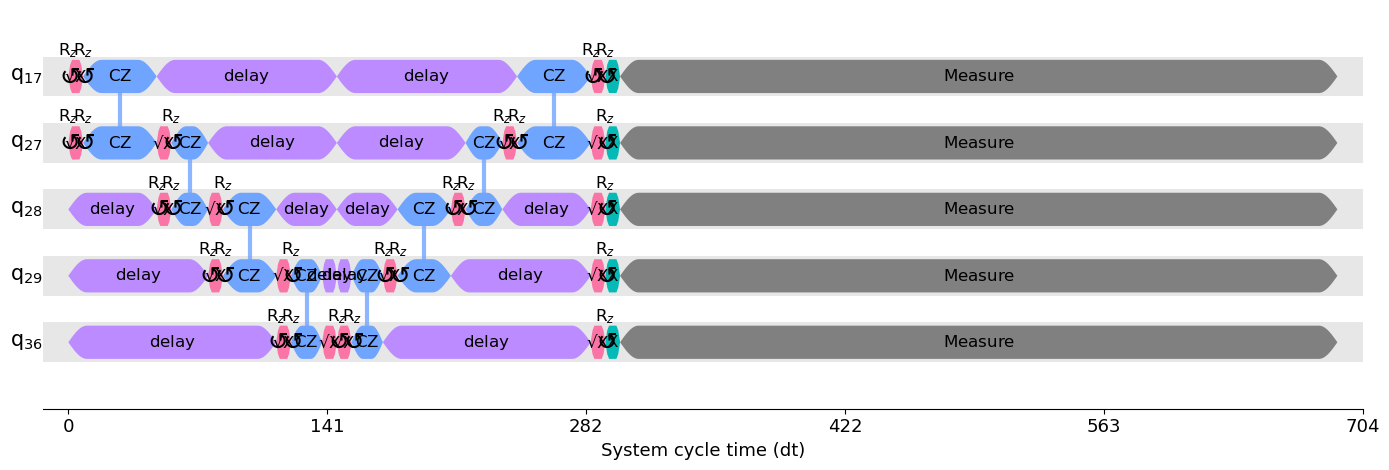

In [11]:
timeline_drawer(generate_preset_pass_manager(torino, 3, scheduling_method='alap').run(prepare_echo_ghz_with_xs(5)),idle_wires=False, target=torino.target, show_barriers=False, show_delays=True)


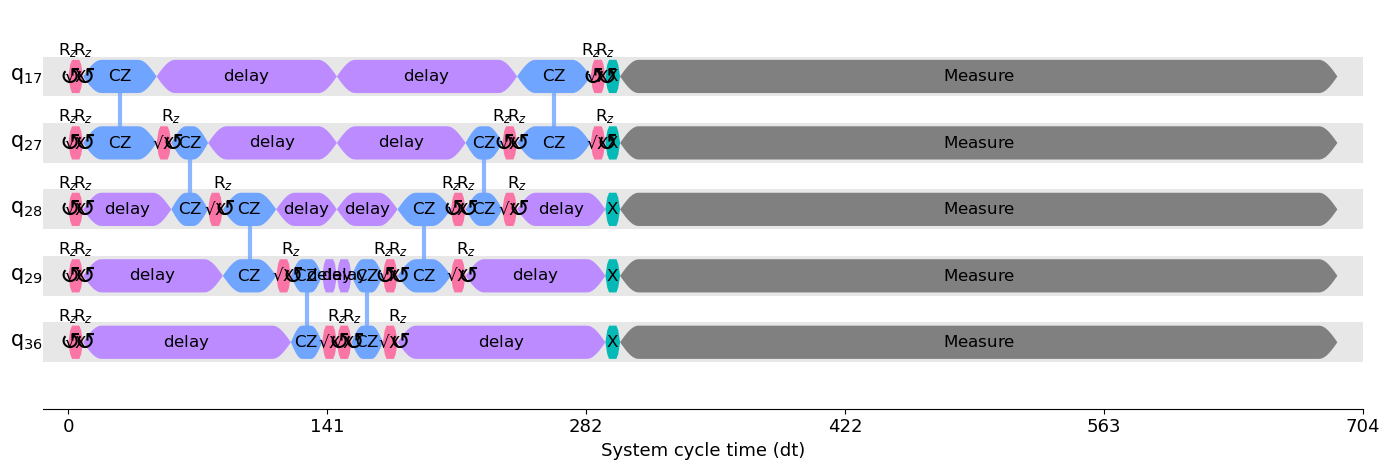

In [12]:
timeline_drawer(generate_preset_pass_manager(torino, 3, scheduling_method='asap').run(prepare_echo_ghz_with_xs(5)),idle_wires=False, target=torino.target, show_barriers=False, show_delays=True)


In [2]:
import dill
# 2. Save Function (Generic for any object)
def save_object(obj, filename):
    try:
        with open(filename, 'wb') as f:
            dill.dump(obj, f)
        print(f"Object saved to '{filename}'")
    except Exception as e:
        print(f"Error saving object: {e}")

# 3. Load Function
def load_object(filename):
    try:
        with open(filename, 'rb') as f:
            obj = dill.load(f)
        print(f"Object loaded from '{filename}'")
        return obj
    except Exception as e:
        print(f"Error loading object: {e}")

In [3]:

def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def gen_param4_eff_su2(n_qubits: int, seed: int, reps: int = 1):
    np.random.seed(seed)
    arr = np.random.normal(loc=0, scale=0.22, size=n_qubits*reps*4)
    return arr

def prepare_eff_su2(n_qubits: int, seed_for_params: int):
    crkt = efficient_su2(num_qubits=n_qubits, reps=1, entanglement="linear")
    crkt.measure_all()
    params = gen_param4_eff_su2(n_qubits, seed_for_params)
    eff_su2_crkt = crkt.assign_parameters(params)

    return eff_su2_crkt


class BenchmarkOptions:
    def __init__(
        self, 
        backend_name: str = "ibm_fez", 
        opt_level: int = 3, 
        do_dd: bool = False,
        scheduling_method: str | None = None, 
        dd_pulse: str | None = None
    ):
        # Allow any backend 
        try:
            self.backend = QiskitRuntimeService().backend(backend_name)
        except Exception as e:
            print(f"Warning: Could not connect to backend '{backend_name}'. {e}")
            self.backend = None

        self.opt_level = opt_level
        self.do_dd = do_dd
        self.dd_pulse = dd_pulse
        self.scheduling_method = scheduling_method
        self.basis_gates = list(self.backend.target.operation_names)

        ## Default pulse sequence is xx
        if self.do_dd and self.dd_pulse is None:
            self.dd_pulse = 'xx'

        


def pm_for_backend(bknd, opt_level:int, seed:int, scheduling_method:str = "none", target:Target | None = None):
    ## Returns a normal (no dd) PassManager from generate_preset_pass_manager for given opt_level and backend(bknd) al
    
    if target is None:
        target = bknd.target
        
    ## for no scheduling case
    if scheduling_method == 'none':
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    
    ## for "alap" and "asap" cases
    else:
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=scheduling_method, target=target)
    
    return pm


def make_passmanager(benchmark_options:BenchmarkOptions):
    
    backend = benchmark_options.backend if benchmark_options.backend else QiskitRuntimeService().backend("ibm_fez")
    opt_level = benchmark_options.opt_level if benchmark_options.opt_level else 3
    scheduling_method = benchmark_options.scheduling_method if benchmark_options.scheduling_method else 'none'

    print(f"Transpilation options:\nbackend:{backend}\noptlevel:{opt_level}\nscheduling:{scheduling_method}\ndo_dd:{benchmark_options.do_dd}\ndd_pulse:{benchmark_options.dd_pulse}")

    ## Fix seed for reprodicubility
    pm_seed = 42069

    ## Include DD
    if benchmark_options.do_dd:
        return prepare_dd_pm(benchmark_options=benchmark_options)

    ## Defaults to no dd PM with opt_level = 3 and given scheduling_method
    else:
        return pm_for_backend(bknd=backend, opt_level=opt_level, seed=pm_seed, scheduling_method=scheduling_method)




def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler

def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        # summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(benchmark_options:BenchmarkOptions):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 

    # Default Sequence
    sequenece = [XGate(), XGate()]

    target = benchmark_options.backend.target

    seq = benchmark_options.dd_pulse

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    if seq.lower() == 'xy':
        from qiskit.transpiler import InstructionProperties

        sequenece = [XGate(), YGate(), XGate(), YGate()]

        y_gate_properties = {}

        for qubit in range(target.num_qubits):
            y_gate_properties.update(
                {
                    (qubit,): InstructionProperties(
                        duration=target["x"][(qubit,)].duration,
                        error=target["x"][(qubit,)].error,
                    )
                }
            )
        
        target.add_instruction(YGate(), y_gate_properties)

    


    ## Prepare a preset passmanager for backend optimization_level=3 and target (target is modified if seq = 'xy)
    pm = pm_for_backend(bknd=benchmark_options.backend, opt_level=3, seed=42069, target=target)

    try:
            
        if benchmark_options.scheduling_method:    
                if benchmark_options.scheduling_method == 'asap':
                    pm.scheduling.append(ASAPScheduleAnalysis(target=target))

                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
                
                elif benchmark_options.scheduling_method == 'alap':
                    pm.scheduling.append(ALAPScheduleAnalysis(target=target))
                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    except:
        print(f"Error in sequence({seq}) or scheduling method({benchmark_options.scheduling_method})")

    return pm




def mega_transpiler(circuit:QuantumCircuit, dd_pm:StagedPassManager, benchmark_options:BenchmarkOptions) -> QuantumCircuit:
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    ## Final Translation to convert Y gates into basis equivalent gates
    if benchmark_options.do_dd is True:
        if benchmark_options.dd_pulse.lower() == 'xy':
            from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
            from qiskit.transpiler.passes import BasisTranslator
            

            basis_gates = benchmark_options.basis_gates
            

            return BasisTranslator(sel, basis_gates)(isa_dd_circuit)
        else:
            return isa_dd_circuit

    ## Normal case for xx dd and xpxm dd
    else:
        return isa_dd_circuit
    



def get_fidelity_for_circuit(ideal, simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated] + dd_counts_list:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]




    


In [4]:
qubits = [7, 8, 9, 10, 17, 18, 19, 20, 27, 28, 29, 30]


methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "asap+dd+xpxm", "alap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]

valid_methods = methods_list + dd_methods_list + extra_dd_methods_list

isa_circuits_dict = load_object("extensive_benchmarking_ghz_isa_circuits.dill")
hardware_job_dict = load_object("extensive_benchmarking_ghz_hardware_job.dill")


service = QiskitRuntimeService()

fez = service.backend("ibm_fez")

backend = AerSimulator().from_backend(fez)




management.get:WARNING:2025-12-17 13:25:25,237: Loading default saved account


Object loaded from 'extensive_benchmarking_ghz_isa_circuits.dill'
Object loaded from 'extensive_benchmarking_ghz_hardware_job.dill'


In [5]:

pub = [(prepare_ghz(qubit)) for qubit in qubits]





In [6]:
with Batch(backend=backend) as batch:
    sampler = naked_sampler(mode=batch)
    job = sampler.run(pub, shots=4096)
    result = job.result()


/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': False, 'enable_measure': False}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


AerError: 'unknown instruction: h'

In [ ]:
simulated_counts = { result[i].data.meas.num_bits:result[i].data.meas.get_counts() for i in range(len(result)) }
save_object(simulated_counts, 'fez_ghz_simulated_counts.dill')